In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Cargar datos
...

Ellipsis

In [ ]:
import pandas as pd

# Cargar train
train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
print("Shape train:", train.shape)
train.head()

cols = (["engine_id", "cycle"] +
        ["setting1", "setting2", "setting3"] +
        [f"s{i}" for i in range(1, 22)])

train.columns = cols
train.head()

#SHAPE TRAIN NOS DICE QUE HAY 20631 FILAS Y 26 COLUMNAS, OSEA 20631 CICLOS Y 26 VARIABLES
#LA NASA NO TIENE PUBLICADO CUALES SON CADA UNA DE ESTAS VARIABLES, EN PRINCIPIO PARA ENTRENAR NO NECESITO SABER QUE ES CADA SENSOR.
#EL MODELO VE SERIES NUMERICAS, APRENDE PATRONES DE DEGRADACIÓN Y RELACIONA LOS PATRONES CON LA RUL


Shape train: (20631, 26)


,engine_id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:

max_cycle = train.groupby("engine_id")["cycle"].max()
train["RUL"] = train.apply(lambda r: max_cycle[r["engine_id"]] - r["cycle"], axis=1)

train[["engine_id", "cycle", "RUL"]].head(10)



,engine_id,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0
5,1,6,186.0
6,1,7,185.0
7,1,8,184.0
8,1,9,183.0
9,1,10,182.0


In [ ]:
## FEATURE SELECTION USING CORRELATION
#Queremos ver qué variables (settings y sensores) tienen más relación con la RUL.
#Las que tengan muy poca relación, en principio aportan menos al modelo.
# 1) Elegimos las columnas que queremos estudiar
features = ["setting1", "setting2", "setting3"] + [f"s{i}" for i in range(1, 22)]

# 2) Calculamos la correlación de cada variable con la RUL
corr_with_rul = train[features + ["RUL"]].corr()["RUL"].drop("RUL")
#2.1) PONER EN VALOR ABSOLUTO
corr_with_rul = corr_with_rul.abs()
# 3) Mostramos las correlaciones ordenadas
corr_with_rul = corr_with_rul.sort_values(ascending=False)

print(corr_with_rul)

#correlación cerca de 1 → suben o bajan juntas
#correlación cerca de -1 → una sube y la otra baja
#correlación cerca de 0 → casi no tienen relación

#LOS NAN SIGNIFICAN QUE ESAS VARIABLES NO TIENEN VARIACIÓN, O CASI NO LA TIENEN, Y POR ESO LA CORRELACIÓN NO SE PUEDE CALCULAR BIEN.
#ESAS VARIABLES NO SIRVEN O APORTAN MUY POCO PARA EL MODELO.

##LO QUE NOS IMPORTAN SON LOS VALORES ABSOLUTOS POR LO QUE LA FUNCION LA PONEMOS EN ABSOLUTOS POR ESO EL PASO 2.1
# 4) Nos quedamos solo con las variables que tengan correlación alta
hold = 0.5 ##PONER TODO JUNTO EN UNA CELDA
#0.5 PARA QUEDARNOS CON LO IMPORTANTE

good_features = corr_with_rul[corr_with_rul > hold].index.tolist()

print("Sensores/variables seleccionados:")
print(good_features)

# 5) Creamos un nuevo dataset solo con las variables buenas + RUL
train_selected = train[good_features + ["RUL"]].copy()

print("Shape del dataset filtrado:")
print(train_selected.shape)

train_selected.head()

##VER LA CORRELACIÓN DE VARIABLES QUE SE COMPLEMENTEN!!!


s11         0.696228
s4          0.678948
s12         0.671983
s7          0.657223
s15         0.642667
s21         0.635662
s20         0.629428
s2          0.606484
s17         0.606154
s3          0.584520
s8          0.563968
s13         0.562569
s9          0.390102
s14         0.306769
s6          0.128348
setting1    0.003198
setting2    0.001948
setting3         NaN
s1               NaN
s5               NaN
s10              NaN
s16              NaN
s18              NaN
s19              NaN
Name: RUL, dtype: float64
Sensores/variables seleccionados:
['s11', 's4', 's12', 's7', 's15', 's21', 's20', 's2', 's17', 's3', 's8', 's13']
Shape del dataset filtrado:
(20631, 13)


,s11,s4,s12,s7,s15,s21,s20,s2,s17,s3,s8,s13,RUL
0,47.47,1400.60,521.66,554.36,8.4195,23.4190,39.06,641.82,392,1589.70,2388.06,2388.02,191.0
1,47.49,1403.14,522.28,553.75,8.4318,23.4236,39.00,642.15,392,1591.82,2388.04,2388.07,190.0
2,47.27,1404.20,522.42,554.26,8.4178,23.3442,38.95,642.35,390,1587.99,2388.08,2388.03,189.0
3,47.13,1401.87,522.86,554.45,8.3682,23.3739,38.88,642.35,392,1582.79,2388.11,2388.08,188.0
4,47.28,1406.22,522.19,554.00,8.4294,23.4044,38.90,642.37,393,1582.85,2388.06,2388.04,187.0


In [ ]:
## MOVING MEDIAN FILTER
#VAMOS A SUAVIZAR LOS SENSORES PARA QUITAR PICOS RAROS.

window_size = 5 # EL FILTRO MIRARÁ UNA VENTANA DE 5 DATOS ALREDEDOR, Y SUSTITUIRÁ EL VALOR POR LA MEDIANA
sensor_cols = good_features.copy() #GUARDAMOS LA LISTA DE SENSORES BUENOS
train_filtered = train_selected.copy() #CREAMOS UNA COPIA PARA NO TOCAR EL ORIGINAL

for col in sensor_cols:
    train_filtered[col] = train_filtered[col].rolling(window=window_size, center=True).median() #EL CENTER SIRVE PARA QUE SE COJAN LOS DE ALREDEDOR DEL VALOR ACTUAL.
    #ROLLING HACE QUE COJAS UN TROZO DE SEÑAL Y LO VAYAS DESLIZANDO.
    #COMO AL SER UNA VENTANA DE 5 CON LOS DOS PRIMERO NO FUNCIONARÁ, TENEMOS QUE CREAR UNA FUNCIÓN QUE QUITE LOS NaN. QUE SON VALORES VACIOS.
    train_filtered = train_filtered.dropna()

train_filtered.head()

,s11,s4,s12,s7,s15,s21,s20,s2,s17,s3,s8,s13,RUL
24,47.36,1398.81,522.13,554.00,8.4046,23.4288,38.95,642.38,393.0,1590.47,2388.05,2388.05,167.0
25,47.37,1399.13,522.28,554.07,8.4046,23.4149,38.99,642.38,393.0,1590.47,2388.07,2388.06,166.0
26,47.36,1399.39,522.41,554.11,8.4189,23.4149,38.95,642.35,393.0,1589.08,2388.05,2388.06,165.0
27,47.37,1399.13,522.28,554.25,8.4189,23.4110,38.99,642.20,393.0,1589.08,2388.07,2388.06,164.0
28,47.40,1399.13,522.19,554.25,8.4104,23.3597,38.99,642.20,392.0,1584.83,2388.07,2388.06,163.0


In [ ]:
## NORMALIZACIÓN
#NUESTRO OBJETIVO AQUI ES PONER TODAS LAS VARIABLES EN UNA MISMA ESCALA, DEBEMOS PASAR TODOS LOS VALORES ENTRE 0 Y 1. SOLO NORMALIZAREMOS LOS SENSORES, NO LA RUL.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() # CONVIERTE TODOS LOS VALORES ENTRE 0 Y 1

# columnas de sensores (sin la RUL)
sensor_cols = good_features.copy()

# copiamos el dataset filtrado
train_normalized = train_filtered.copy()

# aplicamos la normalización SOLO a sensores
train_normalized[sensor_cols] = scaler.fit_transform(train_filtered[sensor_cols]) #.FIT_TRANSFORM APRENDE LOS RANGOS Y TRANSFORMA
# NO NORMALIZAMOS LA RUL PORQUE NO QUEREMOS PERDER INTERPRETACIÓN DIRECTA
train_normalized.head()

,s11,s4,s12,s7,s15,s21,s20,s2,s17,s3,s8,s13,RUL
24,0.300000,0.208390,0.763224,0.721133,0.222465,0.828211,0.705263,0.326531,0.375,0.467954,0.275,0.275,167.0
25,0.307692,0.215646,0.801008,0.736383,0.222465,0.801680,0.747368,0.326531,0.375,0.467954,0.325,0.300,166.0
26,0.300000,0.221542,0.833753,0.745098,0.300436,0.801680,0.705263,0.314286,0.375,0.427275,0.275,0.300,165.0
27,0.307692,0.215646,0.801008,0.775599,0.300436,0.794236,0.747368,0.253061,0.375,0.427275,0.325,0.300,164.0
28,0.330769,0.215646,0.778338,0.775599,0.254089,0.696316,0.747368,0.253061,0.250,0.302897,0.325,0.300,163.0


In [ ]:
## UNA VEZ TENEMOS ESTO, DEBEMOS SEPARARLO EN INPUT Y OUTPUT, INPUT SERÁN LOS SENSORES Y OUTPUT SERÁ LA RUL.
## SEPARAR INPUT DATA Y OUTPUT LABEL
# X serán los sensores normalizados
# y será la RUL

X = train_normalized[sensor_cols].copy()
y = train_normalized["RUL"].copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

X.head()


Shape de X: (20583, 12)
Shape de y: (20583,)


,s11,s4,s12,s7,s15,s21,s20,s2,s17,s3,s8,s13
24,0.300000,0.208390,0.763224,0.721133,0.222465,0.828211,0.705263,0.326531,0.375,0.467954,0.275,0.275
25,0.307692,0.215646,0.801008,0.736383,0.222465,0.801680,0.747368,0.326531,0.375,0.467954,0.325,0.300
26,0.300000,0.221542,0.833753,0.745098,0.300436,0.801680,0.705263,0.314286,0.375,0.427275,0.275,0.300
27,0.307692,0.215646,0.801008,0.775599,0.300436,0.794236,0.747368,0.253061,0.375,0.427275,0.325,0.300
28,0.330769,0.215646,0.778338,0.775599,0.254089,0.696316,0.747368,0.253061,0.250,0.302897,0.325,0.300


In [ ]:
## CREAR SECUENCIAS TEMPORALES PARA LA LSTM
# La LSTM no trabaja con filas sueltas, sino con secuencias de varios ciclos seguidos.
# Vamos a crear ventanas temporales de longitud fija para cada motor.
# La etiqueta de cada secuencia será la RUL del último ciclo de esa ventana.

import numpy as np

sequence_length = 10  # número de ciclos que tendrá cada secuencia

# Recuperamos el engine_id usando los mismos índices que tiene train_normalized
engine_ids = train.loc[train_normalized.index, "engine_id"].reset_index(drop=True)

# Reiniciamos índices para que todo quede alineado
X_seq_df = X.reset_index(drop=True).copy()
y_seq_df = y.reset_index(drop=True).copy()

# Añadimos engine_id al dataframe de entrada
X_seq_df["engine_id"] = engine_ids

# Listas donde guardaremos las secuencias y sus etiquetas
X_lstm = []
y_lstm = []

# Recorremos cada motor por separado
for engine in X_seq_df["engine_id"].unique():

    # Filtramos los datos de ese motor
    engine_data = X_seq_df[X_seq_df["engine_id"] == engine].copy()
    engine_rul = y_seq_df[X_seq_df["engine_id"] == engine].copy()

    # Quitamos engine_id de las entradas, porque no es un sensor
    engine_data = engine_data.drop(columns=["engine_id"])

    # Creamos ventanas deslizantes
    for i in range(len(engine_data) - sequence_length + 1):
        X_window = engine_data.iloc[i:i+sequence_length].values
        y_value = engine_rul.iloc[i+sequence_length-1]

        X_lstm.append(X_window)
        y_lstm.append(y_value)

# Convertimos a arrays numpy
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("Shape de X_lstm:", X_lstm.shape)
print("Shape de y_lstm:", y_lstm.shape)

#print(X_lstm[0])
#print(y_lstm[0])
#17683 muestras
#30 ciclos por muestra
#12 sensores por ciclo

Shape de X_lstm: (19683, 10, 12)
Shape de y_lstm: (19683,)


In [ ]:
## DEFINIR LA RED LSTM
# Vamos a construir la arquitectura de la red neuronal.
# Tendrá varias capas LSTM con capas Dropout intermedias para evitar overfitting.
# La salida final será un único valor: la RUL predicha.

from tensorflow.keras.models import Sequential #modelo en cadena, una capa detras de otra
from tensorflow.keras.layers import LSTM, Dropout, Dense
#LSTM. capas para modelos temporales
#Dropout. para evitar que dependa siempre de las mismas neuronas, apaga aleatoriamente un x por ciento.
model = Sequential()

# Capa 1
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
model.add(Dropout(0.2))
#Añade la primera capa LSTM que tendrá 64 neuronas, generando 64 valores de salida en cada paso temporal
#el return_sequences es para que devuelva la secuencia completa y no solo el final, lo necesitamos porque despues va otra LSTM
#el input_shape es para darle la forma de la entrada
#el dropout apaga el 20% de las neuronas aleatoriamente durante el entrenamiento con la finalidad de no memorizar
# EN RESÚMEN : La primera capa coge una secuencia de 30 ciclos con 12 sensores y empieza a aprender patrones temporales.

# Capa 2
model.add(LSTM(units=32, return_sequences=True))
model.add(Dropout(0.2))
#creamos otra capa LSTM en cadena con la anterior pero ahora usamos 32 neuronas.
#seguimos devolviendo la secuencia entera porque tenemos otra LSTM detrás.
#La primera capa detecta patrones más amplios, esta capa vuelve a procesar la información y la comprime un poco mas.

# Capa 3
model.add(LSTM(units=16, return_sequences=True))
model.add(Dropout(0.2))
#La idea es seguir reduciendo y refinando la información

# Capa 4
model.add(LSTM(units=8, return_sequences=False))
model.add(Dropout(0.2))
#en esta capa cogemos únicamente 8 neuronas y no devolvemos la secuencia completa, solo el resultado final.
#Nos quedamos con el resúmen de todo lo aprendido.

#64 → veo todo
#32 → me quedo con lo importante
#16 → simplifico
#8 → conclusión final

#AHORA VAMOS A TRABAJAR CON EL RESÚMEN SACADO DE LA ÚLTIMA CAPA LSTM.

# Fully Connected Layer 1
model.add(Dense(16, activation='relu'))
###MUY IMPORTANTE. DENSE (16) CREA 16 VALORES A PARTIR DE LOS 8. ESTO QUIERE DECIR QUE CREA COMBINACIONES CON ESOS VALORES
###HACE RELACIONES ENTRE LOS VALORES PARA MEJORAR LA PREDICCIÓN FINAL.
model.add(Dropout(0.2))
#activation hace que la red pueda aprender relaciones no lineales.
#ESTA CAPA COMBINA Y ORGANIZA LA INFORMACIÓN

# Fully Connected Layer 2
model.add(Dense(8, activation='relu'))
### AL REDUCIR A DENSE(8) LO QUE HEMOS HECHO ES, DE LAS 16 COMBINACIONES ANTERIORES, NOS QUEDAMOS CON LAS MÁS RELEVANTES.
model.add(Dropout(0.2))
#es otro refinado.

# Capa de salida
model.add(Dense(1))
#Devuelve un único número, es decir la RUL predicha.
#Toda la red termina dando una sola salida: cuánta vida útil le queda al motor.
#ESTO ES LA CAPA DE REGRESIÓN

# Resumen del modelo
model.summary()

#MIRAMOS PRIMERA CAPA
#Significa:

#None = número de muestras, que puede variar
#30 = longitud de la secuencia
#64 = salida de 64 neuronas por cada instante temporal

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 10, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 10, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,353 (142.00 KB)

 Trainable params: 36,353 (142.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## COMPILAR Y ENTRENAR EL MODELO
# Aquí le decimos al modelo cómo va a aprender y luego lo entrenamos con los datos.

model.compile( # CONFIGURAMOS EL APRENDIZAJE DEL MODELO
    optimizer='adam', #ALGORITMO QUE AJUSTA LOS PESOS PARA APRENDER
    loss='mse', #FUNCIÓN DE ERROR PRINCIPAL, COMPARA RUL PREDICHA CON LA REAL
    metrics=['mae'] #ERROR MEDIO ABSOLUTO
)

history = model.fit( #ENTRENAMOS EL MODELO
    X_lstm, #ENTRADAS
    y_lstm, #SALIDAS REALES
    #epochs=20, #CUANTAS VECES RECORRE TODOS LOS DATOS
    epochs=20,
    batch_size=32, #MUESTRAS USADAS EN CADA PASO
    validation_split=0.2, #RESERVA EL 20% PARA VALIDACIÓN
    verbose=1 #MUESTRA EL PROGRESO EN LA PANTALLA
)

Epoch 1/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 8282.8252 - mae: 72.6050 - val_loss: 6417.7998 - val_mae: 63.5542
Epoch 2/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 4921.5664 - mae: 56.7418 - val_loss: 6337.6294 - val_mae: 63.3380
Epoch 3/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 3728.4221 - mae: 46.3813 - val_loss: 2970.5596 - val_mae: 39.1689
Epoch 4/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 2588.7361 - mae: 36.3992 - val_loss: 2970.2473 - val_mae: 38.2908
Epoch 5/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 2421.7898 - mae: 34.9155 - val_loss: 2803.0627 - val_mae: 36.8399
Epoch 6/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 2414.2024 - mae: 34.8696 - val_loss: 2613.7822 - val_mae: 36.1216
Epoch 7/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 2340.3574 - mae: 34.1734 - val_loss: 3035.9070 - val_mae: 37.8845
Epoch 8/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - loss: 2293.9822 - mae: 34.0031 - val_loss: 2855.

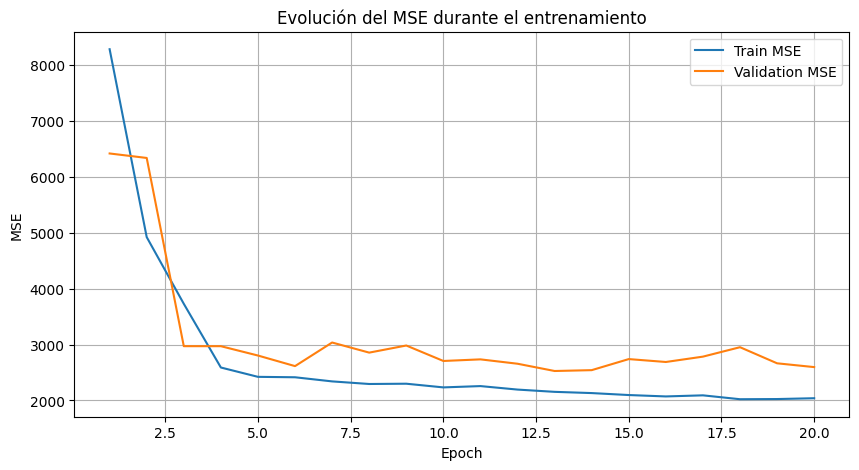

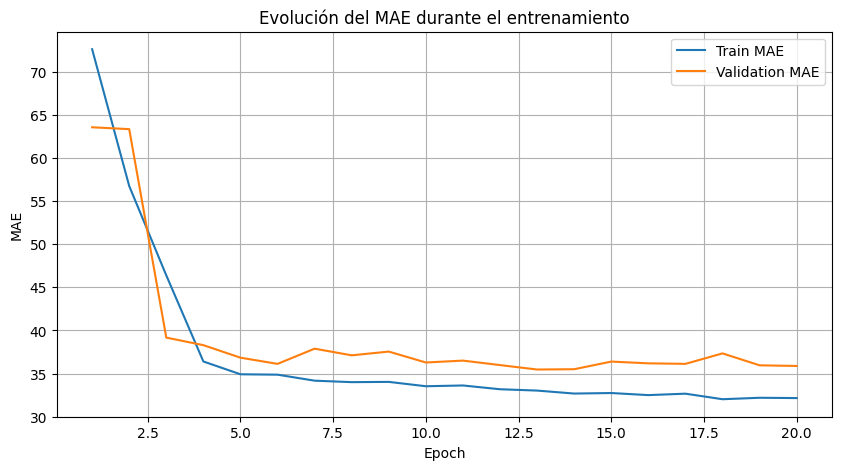

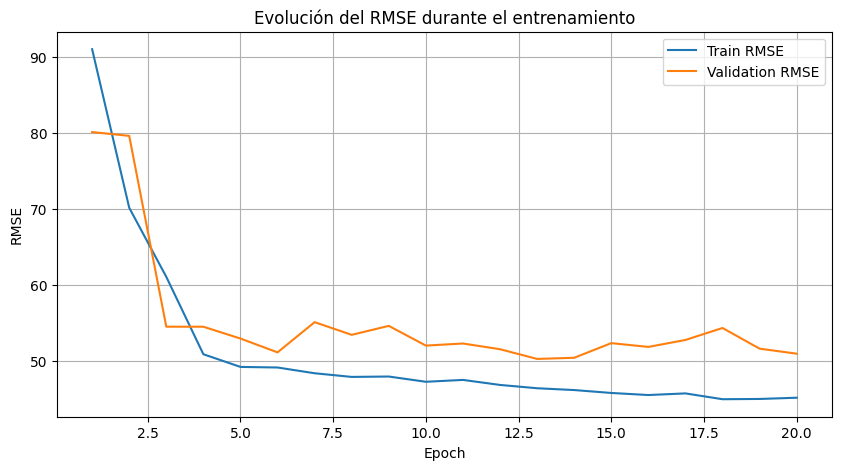

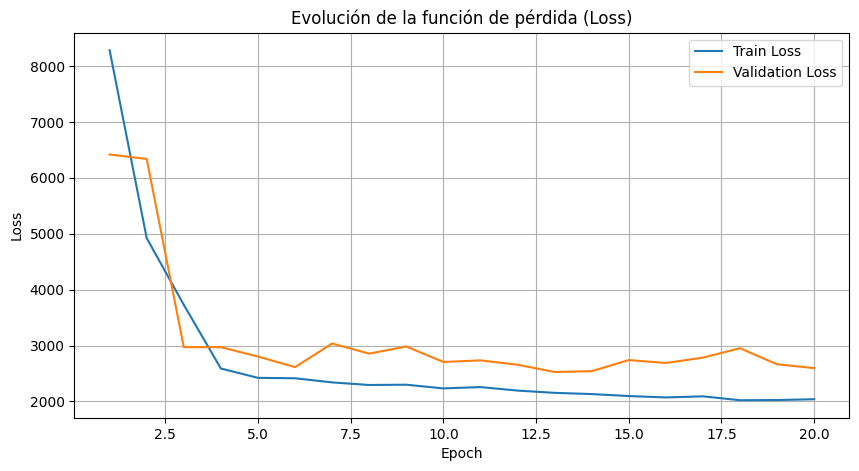

In [ ]:
## CURVAS DE APRENDIZAJE: TRAIN Y VALIDATION
# Aquí representamos la evolución de las métricas a lo largo de las epochs.
# Como la loss es MSE, también calculamos RMSE a partir de ella.

import matplotlib.pyplot as plt
import numpy as np

# Número de epochs
epochs = range(1, len(history.history["loss"]) + 1) #creamos la lista para el eje x

# Métricas guardadas
train_mse = history.history["loss"]           # porque loss = mse
val_mse = history.history["val_loss"] #history.history es para guardar los valores

train_mae = history.history["mae"]
val_mae = history.history["val_mae"]

# RMSE calculado a partir del MSE
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

# ---------------------------
# 1) MSE
# ---------------------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_mse, label="Train MSE")
plt.plot(epochs, val_mse, label="Validation MSE")
plt.title("Evolución del MSE durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 2) MAE
# ---------------------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_mae, label="Train MAE")
plt.plot(epochs, val_mae, label="Validation MAE")
plt.title("Evolución del MAE durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 3) RMSE
# ---------------------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_rmse, label="Train RMSE")
plt.plot(epochs, val_rmse, label="Validation RMSE")
plt.title("Evolución del RMSE durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 4) LOSS
# ---------------------------
# Dado que la función de pérdida seleccionada es el MSE, las curvas de pérdida coinciden con las de MSE.
plt.figure(figsize=(10,5))
plt.plot(epochs, train_mse, label="Train Loss")
plt.plot(epochs, val_mse, label="Validation Loss")
plt.title("Evolución de la función de pérdida (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## TEST PHASE (predicción) con los datos sacados por nuestra cuenta

#y_pred = model.predict(X_lstm)

#print(y_pred[:10])
#print(y_lstm[:10])

Shape test: (13096, 26)
Shape rul_test: (100, 1)
Shape test_filtered: (12696, 14)
Shape test_normalized: (12696, 14)
Shape de X_test: (100, 10, 12)
Shape de y_test: (100,)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step
Primeras 10 predicciones: [131.95787  142.15277   59.81378  111.02826  114.8099   127.218605
 101.35018  117.0529   131.90413  109.7227  ]
Primeras 10 RUL reales: [112  98  69  82  91  93  91  95 111  96]
MSE test: 690.3984985351562
MAE test: 19.722288131713867
RMSE test: 26.27543526823402


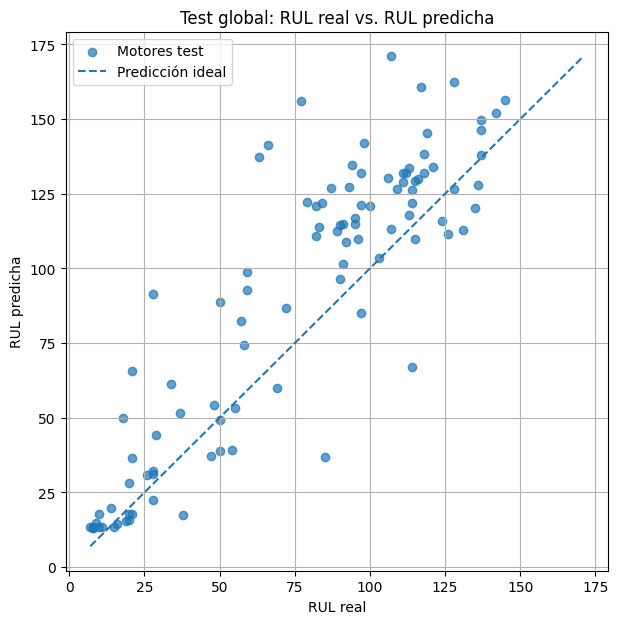

In [ ]:
## TEST PHASE REAL
# Aquí usamos datos nuevos que el modelo no ha visto.
# Reutilizamos lo que ya tenemos del train:
# sensor_cols, window_size, scaler, sequence_length y model

from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 1) CARGAR SOLO EL TEST Y SU RUL REAL
test = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None)
rul_test = pd.read_csv("RUL_FD001.txt", sep=r"\s+", header=None)

cols = (["engine_id", "cycle"] +
        ["setting1", "setting2", "setting3"] +
        [f"s{i}" for i in range(1, 22)])

test.columns = cols
rul_test.columns = ["RUL"]

print("Shape test:", test.shape)
print("Shape rul_test:", rul_test.shape)

# 2) NOS QUEDAMOS CON LOS MISMOS SENSORES QUE EN TRAIN
test_selected = test[["engine_id", "cycle"] + sensor_cols].copy()

# 3) APLICAMOS EL MISMO FILTRO DE MEDIANA MÓVIL
test_filtered_list = []

for engine in test_selected["engine_id"].unique(): #RECORREMOS MOTOR POR MOTOR
    engine_data = test_selected[test_selected["engine_id"] == engine].copy() #COGEMOS SOLO LAS FILAS DEL MOTOR ACTUAL

    for col in sensor_cols:
        engine_data[col] = engine_data[col].rolling(window=window_size, center=True).median() #APLICAR LA MEDIANA A CADA SENSOR

    engine_data = engine_data.dropna() #QUITAMOS LOS NAN DE LOS EXTREMOS
    test_filtered_list.append(engine_data) #GUARDAMOS EL MOTOR FILTRADO EN LA LISTA

test_filtered = pd.concat(test_filtered_list, axis=0) #CONCATENAMOS LOS DATAFRAMES EN UNO SOLO
test_filtered = test_filtered.reset_index(drop=True) #REINICIA EL INDICE(LIMPIEZA)

print("Shape test_filtered:", test_filtered.shape) #PARA VER CUANTAS FILAS QUEDAN

# 4) NORMALIZAMOS CON EL MISMO SCALER DEL TRAIN
test_normalized = test_filtered.copy()
test_normalized[sensor_cols] = scaler.transform(test_filtered[sensor_cols]) #TRANSFORMAMOS LOS VALORES ENTRE 0 Y 1

print("Shape test_normalized:", test_normalized.shape) #COMPROBAMOS QUE TIENE EL MISMO TAMAÑO Y SOLO HAN CAMBIADO LOS VALORES

# 5) CREAMOS LAS SECUENCIAS DE TEST
# Para cada motor cogemos solo la última secuencia disponible
X_test = [] #GUARDA SECUENCIAS PARA LSTM
y_test = [] #GUARDA LA RUL

for engine in test_normalized["engine_id"].unique():
    engine_data = test_normalized[test_normalized["engine_id"] == engine].copy()
    engine_features = engine_data[sensor_cols].values #LA RED TRABAJA CON ARRAYS, NO CON DATAFRAMES

    if len(engine_features) >= sequence_length:
        X_window = engine_features[-sequence_length:] #COGE LAS ULTIMAS FILAS DEL MOTOR, PORQUE LA RUL REAL CORRESPONDE AL FINAL DE LA SERIE OBSERVADA.
        X_test.append(X_window) #GUARDA ESA ÚLTIMA SECUENCIA

        # La RUL real del motor está en rul_test
        y_test.append(rul_test.iloc[engine - 1]["RUL"]) #ENGINE MENOS 1 PORQUE PANDAS INDEXA COMO 0,1,2... NO PARTE DEL 1

X_test = np.array(X_test)
y_test = np.array(y_test)
#COMPROBAMOS QUE EL FORMATO SEA CORRECTO
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

# 6) PREDICCIÓN
y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.flatten() #LO CONVIERTE EN UN VECTOR PLANO
#MIRAMOS UNA MUESTRA
print("Primeras 10 predicciones:", y_pred_test[:10])
print("Primeras 10 RUL reales:", y_test[:10])

# 7) MÉTRICAS
mse_test = mean_squared_error(y_test, y_pred_test) #ERROR CUADRÁTICO MEDIO
mae_test = mean_absolute_error(y_test, y_pred_test) #ERROR ABSOLUTO MEDIO
rmse_test = np.sqrt(mse_test) #RAIZ DEL MSE

print("MSE test:", mse_test)
print("MAE test:", mae_test)
print("RMSE test:", rmse_test)

## 8) GRÁFICO DE DISPERSIÓN (SCATTER)
# Cada punto es un motor (no los unimos con líneas)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.7, label="Motores test") # alfa es para la transparencia

# Línea ideal (y = x)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', label="Predicción ideal")

plt.title("Test global: RUL real vs. RUL predicha")
plt.xlabel("RUL real")
plt.ylabel("RUL predicha")
plt.legend()
plt.grid(True)
plt.show()

##ada punto del gráfico representa un motor del conjunto de test, donde el eje horizontal corresponde a la RUL real y el eje vertical a la RUL predicha.
#Se observa una tendencia cercana a la diagonal ideal,
#lo que indica una buena capacidad predictiva del modelo, aunque con cierta dispersión, especialmente en valores altos de RUL.

In [ ]:
## NASA Score Function

def nasa_score(y_true, y_pred):
    score = 0 #para que el socre comience en 0
    #pasamos a recorrer las predicciones de cada uno de los motores
    for i in range(len(y_true)):
        d = y_pred[i] - y_true[i] #para comprobar cual ha sido la diferencia
        if d >= 0: #si la estimación ha sido mayor que la real, sobreestimacion
            score += np.exp(d / 10) - 1 #penalizacion exponencial mas fuerte
        else: #si la estimación ha sido menor que la real, infraestimacion
            score += np.exp(-d / 13) - 1 #penalización exponencial mas floja
    return score

score_test = nasa_score(y_test, y_pred_test)

print("NASA Score:", score_test)

NASA Score: 8542.852199370613
